In [19]:
import model as m
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import Evaluate_results as er
from keras import backend as K
import tensorflow as tf
import tensorflow as tf
from sklearn.preprocessing import MaxAbsScaler


In [20]:
import numpy as np
import umap
import matplotlib.pyplot as plt

# Generate some sample data

def umap_projection(data):
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(data)

    # Visualize the result
    #plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=10, cmap='viridis')
    plt.title('UMAP projection of the sample data')
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')
    plt.colorbar()
    plt.show()
    return embedding



In [21]:
import umap
import matplotlib.pyplot as plt

def umap_projection(data, colors=None):
    """
    Perform UMAP dimensionality reduction and visualize the result.
    
    Parameters:
        data (array-like): The data to perform dimensionality reduction on.
        colors (list, optional): List of colors for each data point. If provided,
            it must have the same length as the number of data points.
    Returns:
        embedding (numpy.ndarray): The resulting embedding after UMAP.
    """
    random_state = 42
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(random_state=random_state)
    embedding = reducer.fit_transform(data)

    # Visualize the result
    plt.figure(figsize=(10, 8))
    if colors is not None:
        if isinstance(colors[0], str):  # If color labels are strings
            plot_results(results=embedding, labels = colors)
        else:  # If color labels are numeric
            plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=colors, cmap='viridis')
            plt.colorbar(label='Color')
            plt.title('UMAP projection of the sample data')
            plt.xlabel('UMAP Component 1')
            plt.ylabel('UMAP Component 2')
            plt.show()
    else:
        plt.scatter(embedding[:, 0], embedding[:, 1], s=10, cmap='viridis')
        plt.title('UMAP projection of the sample data')
        plt.xlabel('UMAP Component 1')
        plt.ylabel('UMAP Component 2')
    #plt.colorbar()
        plt.show()
    


In [22]:
import seaborn as sns

def plot_results(results: pd.DataFrame, labels: pd.DataFrame, print_label:str='Experiment'):
    """
    Plot the results
    """
    # Extract 'experiment' column from original data
    experiment_column = labels
    results= pd.DataFrame(results)
    print(results.columns)
    results[print_label] = experiment_column
    # Plot scatter plot with color according to 'Experiment' column in results DataFrame
    
    # Create scatter plot with hue='Experiment' to group by Experiment category
    sns.scatterplot(x=results[0], y=results[1], hue=print_label, data=results, palette='Set1', alpha=0.8, edgecolor='w')


    plt.legend()
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.show()


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def print_distribution(dataset):
    # Create a 3D scatter plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Extract x, y, z coordinates from the normalized dataset
    x = dataset[:, 0]
    y = dataset[:, 1]
    z = dataset[:, 2]

    # Plot the 3D scatter plot
    ax.scatter(x, y, z)

    # Set labels for each axis
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Set the title of the plot
    plt.title('3D Scatter Plot of Normalized Dataset')

    # Show the plot
    plt.show()


In [24]:
def two_step_normalization(dataset):

    # Initialize the Max Abs Scaler (step 1)
    scaler = MaxAbsScaler()
    # Fit and transform the data Equation (1), the normaization by columns
    scaled_dataset = scaler.fit_transform(dataset)
    # Calculate the norm of each vector in the dataset using Equation (2)
    norms = np.sqrt(np.sum(scaled_dataset**2, axis=1))
    # Apply Equation (3) to calculate the norm of each vector in the dataset
    dataset = np.divide(dataset, norms[:, np.newaxis])    
    # add norm feature
    np.column_stack((dataset, norms))
    # Calculate the norm of each vector in the dataset using Equation (2)
    norms = np.sqrt(np.sum(dataset**2, axis=1))
    # Apply Equation (3) to calculate the norm of each vector in the dataset, yes, again
    dataset = np.divide(dataset, norms[:, np.newaxis]) 

    return dataset
    
    

In [25]:
dataset_path = 'Data/trainign_dataset_51270_microarray_adjusted.csv'
loss = "mse"
optimizer = "adam"
metrics = ["mae"] # ["mae", "mse"]
epochs = 7500
batch_size = 512
validation_split = 0.2
lasso_alpha = 0.0005
two_step_normalization_flag = False


In [26]:


microarray_dataframe = pd.read_csv('Results/microarray_w_selected_genes.csv')
microarray_dataframe_original = pd.read_csv('Results/microarray_w_selected_genes.csv')



In [44]:
training_data=pd.read_csv(dataset_path)

model_helper=m.Model(training_data)


/tmp/ipykernel_45784/1422588542.py:1: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data=pd.read_csv(dataset_path)


In [57]:
microarray_dataframe = pd.read_csv('Data/trainign_dataset_51270_microarray_adjusted.csv')
microarray_dataframe_original = pd.read_csv('Data/trainign_dataset_51270_microarray_adjusted.csv')

microarray_dataframe=m.remove_non_numeric_columns(microarray_dataframe)
microarray_dataframe.drop("Age", axis=1, inplace=True)

z_score_nom_array, _ = m.normalize_train_data(microarray_dataframe.values)
z_score_norm_df = pd.DataFrame(z_score_nom_array, columns=microarray_dataframe.columns)
z_score_norm_df


/tmp/ipykernel_45784/1276170488.py:1: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  microarray_dataframe = pd.read_csv('Data/trainign_dataset_51270_microarray_adjusted.csv')
/tmp/ipykernel_45784/1276170488.py:2: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  microarray_dataframe_original = pd.read_csv('Data/trainign_dataset_51270_microarray_adjusted.csv')


,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,J02843,...,AW050627,AI654857,W22117,AI028241,AI571298,AA149545,C18318,AI219073,AI205180,AI363375
0,0.173536,0.205755,0.406471,5.843925,0.927498,2.868413,1.461905,-0.467890,-0.633410,3.325271,...,1.918981,1.847350,3.824117,-1.937002,2.080107,-1.598554,3.033632,-0.677961,3.723553,2.188975
1,1.709018,1.117290,-0.432606,2.148879,0.386818,1.591773,1.509787,-0.611443,-0.019023,-1.891373,...,0.597517,3.247891,-0.260277,3.192968,0.795417,2.167282,4.948314,3.149098,1.618758,1.095367
2,0.694776,-0.931881,-0.504718,0.215258,-0.009120,-0.757328,-0.077972,-0.791909,-0.937746,0.440832,...,-1.364638,-0.631389,2.398259,-1.777440,-0.912526,0.539044,-0.066234,-0.985210,-1.180152,-0.451852
3,-0.129571,0.518427,-0.976072,1.894255,1.108659,1.955926,0.486429,-0.586834,0.353895,0.897740,...,1.943253,-0.122457,0.012629,-1.015640,1.315264,-1.074022,-1.627160,0.031423,2.601564,-0.333958
4,-0.712210,1.022572,0.686800,0.154594,0.418568,0.537204,-0.138080,0.345233,-0.191909,-0.339857,...,0.877503,-0.044805,-1.220049,0.189543,1.086953,-0.972881,0.337488,-1.016839,-0.931420,-0.357536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1.289779,1.051345,-1.135333,0.542122,1.345261,4.002983,2.968562,5.379943,-1.989944,5.369489,...,0.014820,0.024536,-0.001946,0.020760,-0.004051,-0.000294,0.007617,-0.011156,-0.001942,-0.011085
727,-1.698019,-4.211794,-4.564684,-2.183331,0.164471,-1.035525,-5.419757,-0.633900,-1.340192,-0.642409,...,0.014820,0.024536,-0.001946,0.020760,-0.004051,-0.000294,0.007617,-0.011156,-0.001942,-0.011085
728,1.859155,-1.259281,-1.180159,0.605953,3.342411,0.294672,-1.365652,2.725382,-0.703638,2.902254,...,0.014820,0.024536,-0.001946,0.020760,-0.004051,-0.000294,0.007617,-0.011156,-0.001942,-0.011085
729,2.847040,-1.274100,-1.820632,0.395207,7.180658,3.484871,-2.803581,1.559462,-0.655917,5.910538,...,0.014820,0.024536,-0.001946,0.020760,-0.004051,-0.000294,0.007617,-0.011156,-0.001942,-0.011085


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


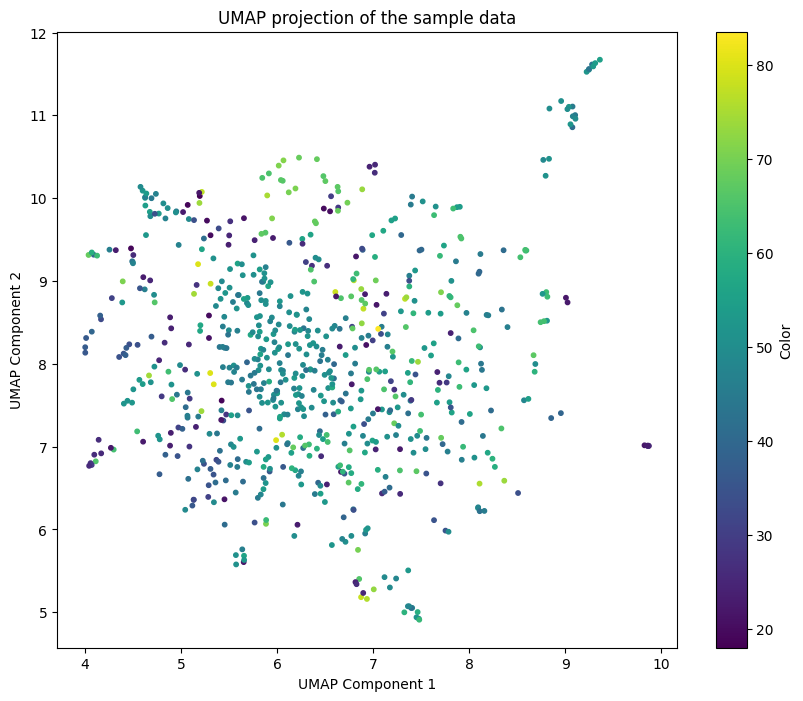

In [58]:
umap_projection(z_score_norm_df, colors=microarray_dataframe_original['Age'])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


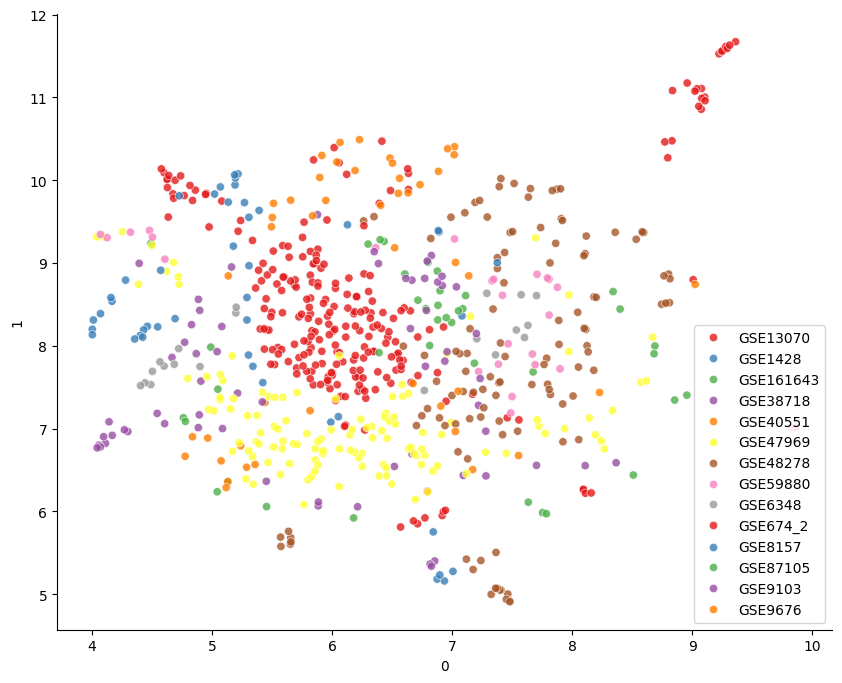

In [59]:
umap_projection(z_score_norm_df, colors=microarray_dataframe_original['Experiment'])

In [52]:
microarray_dataframe = pd.read_csv('Results/microarray_w_selected_genes.csv')
microarray_dataframe_original = pd.read_csv('Results/microarray_w_selected_genes.csv')

microarray_dataframe=m.remove_non_numeric_columns(microarray_dataframe)
microarray_dataframe.drop("Age", axis=1, inplace=True)

z_score_nom_array, _ = m.normalize_train_data(microarray_dataframe.values)
z_score_norm_df = pd.DataFrame(z_score_nom_array, columns=microarray_dataframe.columns)
z_score_norm_df

,NM_001091,NM_033128,BC010094,NM_139011,NM_004796,AB049740,BC036055,AK024889,BC001292,NM_018891,...,BC002426.1,AI922337.1,BC027939.1,NM_152490.1,U91903.1,AF039555.1,NM_153038.1,NM_003468.1,BC039525.1,BC033791.1
0,-0.465434,-0.669658,0.028343,-0.195436,-0.175068,1.224582,-0.050746,0.958005,-0.282195,0.264098,...,-0.937965,-0.423176,-0.866160,0.477161,1.821706,0.543292,1.175857,-0.617636,0.159937,0.344926
1,0.397896,-0.382948,-0.605403,-0.188652,0.085068,0.607182,-1.318345,0.753575,0.325189,-0.508867,...,0.466687,-1.280565,1.679843,-0.060821,-0.570614,-0.286159,0.923043,-0.385584,-0.798378,0.541194
2,1.298621,0.153884,-1.167812,-0.237270,-0.443462,0.040666,-0.436744,-0.090868,1.619086,-1.031458,...,-0.220398,0.415684,-0.386591,-1.017158,-0.298253,-0.607096,-1.734955,-1.050801,0.466494,-0.879501
3,-0.912545,0.342142,0.230190,-0.236139,0.881991,-1.233145,-0.174647,0.360749,0.365486,-0.893669,...,0.032788,0.301141,-0.772585,-0.224198,2.991569,-2.049132,0.609443,0.747176,-0.123436,0.937332
4,-0.645904,0.465207,0.405493,-0.167736,-0.600369,0.444351,0.482980,1.062224,-1.061757,3.700430,...,-0.509353,-0.625311,-0.373920,-1.488832,-0.847026,1.385207,0.411890,-0.574664,0.082653,0.267499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,-0.488557,-2.889507,-0.612096,-4.401081,0.832103,-0.029078,-0.476591,-0.002590,-0.271022,-0.451773,...,-0.026847,-0.001181,-0.034817,-2.447636,-0.236003,-0.145462,-0.113480,0.067535,1.608646,-0.073588
773,-0.303500,-6.211440,-1.583674,-5.950818,-0.089253,-0.000715,-0.387857,-0.002590,-0.104338,-0.413511,...,-0.009690,-0.001181,-0.014084,-0.999248,-0.061378,0.450471,0.046856,-0.081614,-2.041289,-0.054474
774,-0.451565,0.229954,-0.460543,-5.659225,-0.077142,0.013921,-0.363545,-0.002590,-0.080271,-0.401283,...,-0.017169,-0.001181,-0.011682,-0.387915,-0.498841,-0.346857,-0.383440,-0.285040,-1.141264,-0.043419
775,3.931562,-1.782699,2.852775,-5.923777,-0.234012,-0.113915,-0.526056,-0.002590,-0.266171,-0.534996,...,-0.035993,-0.001181,-0.053060,-1.091810,-0.013886,-0.181224,1.579609,0.757081,-3.740206,-0.110011


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


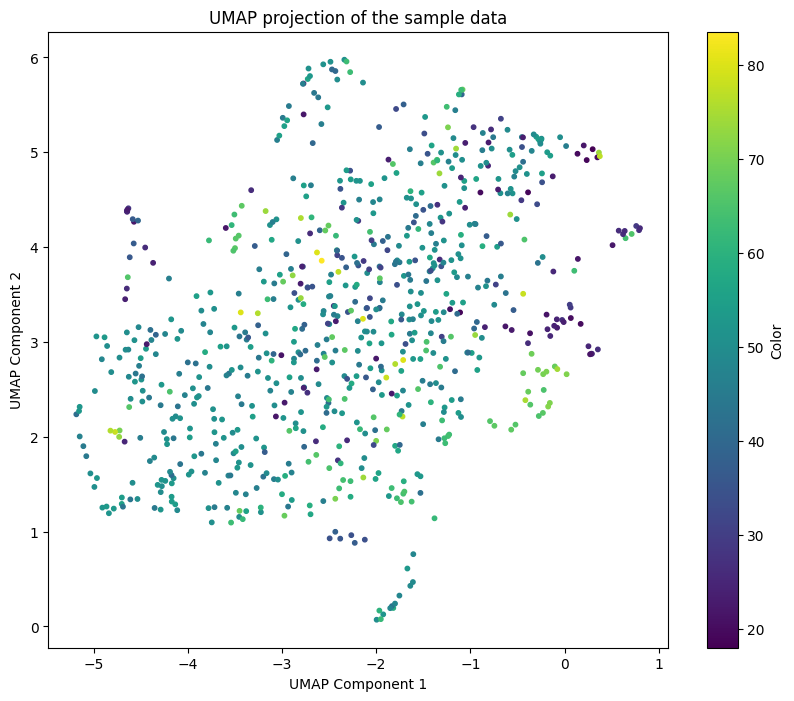

In [53]:
umap_projection(z_score_norm_df, colors=microarray_dataframe_original['Age'])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


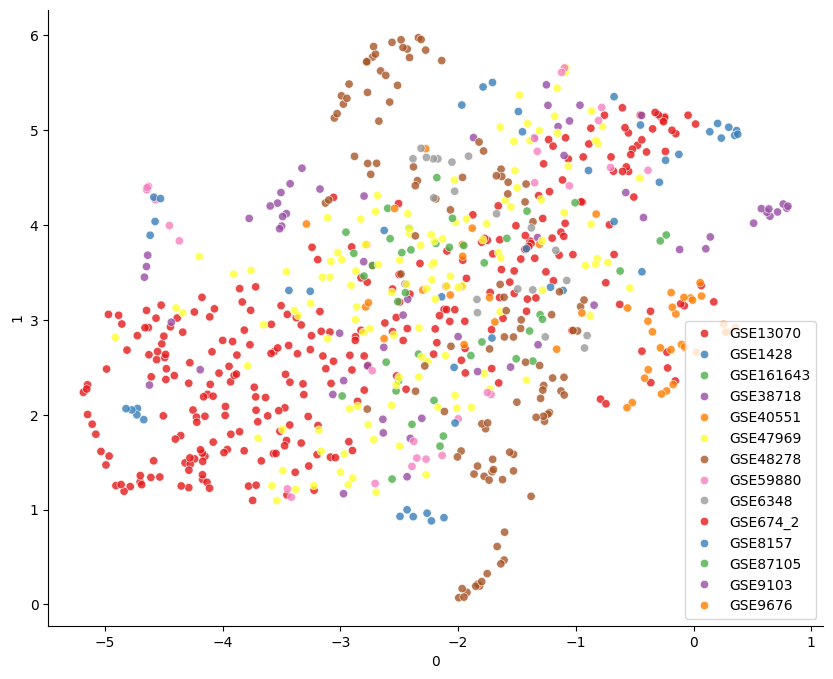

In [54]:
umap_projection(z_score_norm_df, colors=microarray_dataframe_original['Experiment'])

Let's do the double normalization based on  https://www.mdpi.com/2227-7390/10/11/1942#:~:text=The%20proposed%20two-step%20data,to%20separate%20these%20two%20vectors. 


In [46]:
microarray_dataframe = pd.read_csv('Results/microarray_w_selected_genes.csv')

microarray_dataframe=m.remove_non_numeric_columns(microarray_dataframe)
microarray_dataframe.drop("Age", axis=1, inplace=True)
#two_step_nom_array = two_step_normalization(microarray_dataframe.values)
two_step_nom_array= model_helper.two_step_normalization(microarray_dataframe)

two_step_norm_df = pd.DataFrame(two_step_nom_array, columns=microarray_dataframe.columns)
two_step_norm_df

,NM_001091,NM_033128,BC010094,NM_139011,NM_004796,AB049740,BC036055,AK024889,BC001292,NM_018891,...,BC002426.1,AI922337.1,BC027939.1,NM_152490.1,U91903.1,AF039555.1,NM_153038.1,NM_003468.1,BC039525.1,BC033791.1
0,-0.434484,-0.800280,0.084873,-0.240954,-0.169438,1.329534,-0.039747,1.134047,-0.317670,0.338242,...,-1.054340,-0.409348,-0.881223,0.446432,1.764434,0.660481,1.379450,-0.695210,0.234693,0.381520
1,0.685626,-0.643921,-0.950614,-0.335779,0.159169,0.952463,-2.068526,1.273832,0.506467,-0.732798,...,0.662018,-1.937413,2.363404,-0.166844,-0.797147,-0.400814,1.553421,-0.626654,-1.237428,0.835081
2,1.486859,0.274522,-1.310001,-0.296811,-0.471474,0.065874,-0.470172,-0.053887,1.793619,-1.068987,...,-0.290817,0.501523,-0.410494,-1.188943,-0.295129,-0.626514,-2.042954,-1.169448,0.585919,-0.914468
3,-1.151980,0.623473,0.380948,-0.362835,1.231237,-1.607556,-0.221980,0.555222,0.490635,-1.137419,...,-0.009700,0.450294,-0.970330,-0.373472,3.588797,-2.765188,0.886881,0.950740,-0.117844,1.237715
4,-0.280794,0.375161,0.286344,-0.100582,-0.308068,0.259410,0.282451,0.651495,-0.591811,2.048181,...,-0.325121,-0.290248,-0.208904,-0.881469,-0.413885,0.827217,0.246480,-0.342969,0.101011,0.159818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,-0.493208,-3.932112,-0.699396,-5.889695,1.003120,-0.011044,-0.542489,0.046914,-0.324433,-0.463870,...,-0.083511,0.046380,-0.060319,-2.901277,-0.246283,-0.116083,-0.135378,0.040591,1.983835,-0.063020
773,-0.148301,-5.275798,-1.155958,-4.946982,-0.041082,0.021484,-0.266304,0.048095,-0.083024,-0.240590,...,-0.059858,0.046894,-0.032862,-0.789637,-0.042075,0.387333,0.041859,-0.093656,-1.466795,-0.018607
774,-0.427356,0.376286,-0.487909,-7.234337,-0.062523,0.037092,-0.390835,0.047054,-0.096886,-0.385360,...,-0.071644,0.046441,-0.035397,-0.500258,-0.494414,-0.336005,-0.449521,-0.345172,-1.252987,-0.027127
775,2.299248,-1.147180,1.780804,-3.910542,-0.111712,-0.041874,-0.288151,0.048493,-0.160918,-0.248738,...,-0.073194,0.047067,-0.051228,-0.694833,-0.009791,-0.049773,0.974634,0.388115,-2.159547,-0.041456


In [29]:
microarray_dataframe_original['Age']

0      52.50
1      50.60
2      56.08
3      54.84
4      51.14
       ...  
772    65.10
773    68.40
774    65.90
775    67.30
776    67.90
Name: Age, Length: 777, dtype: float64

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


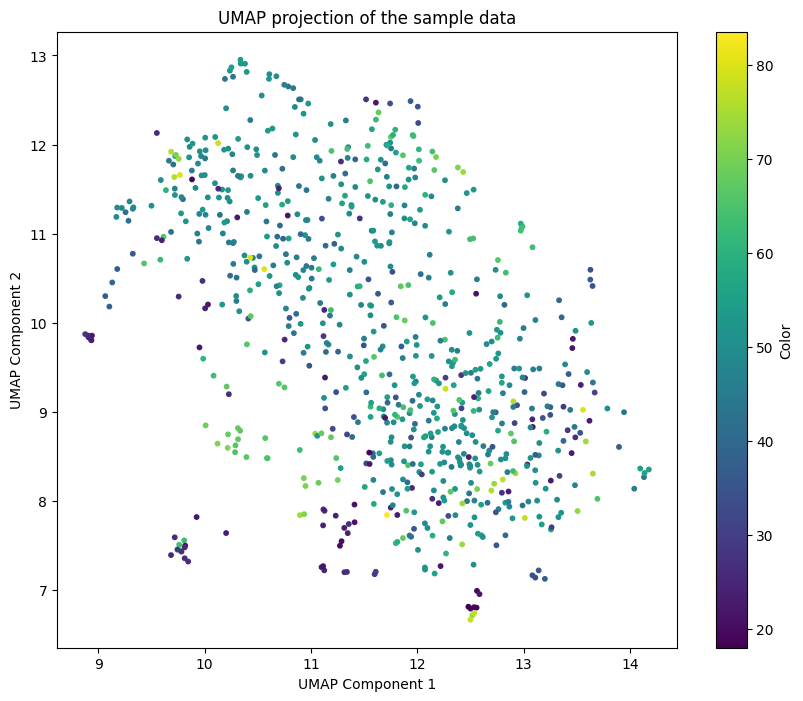

In [47]:
umap_projection(two_step_norm_df, colors=microarray_dataframe_original['Age'])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


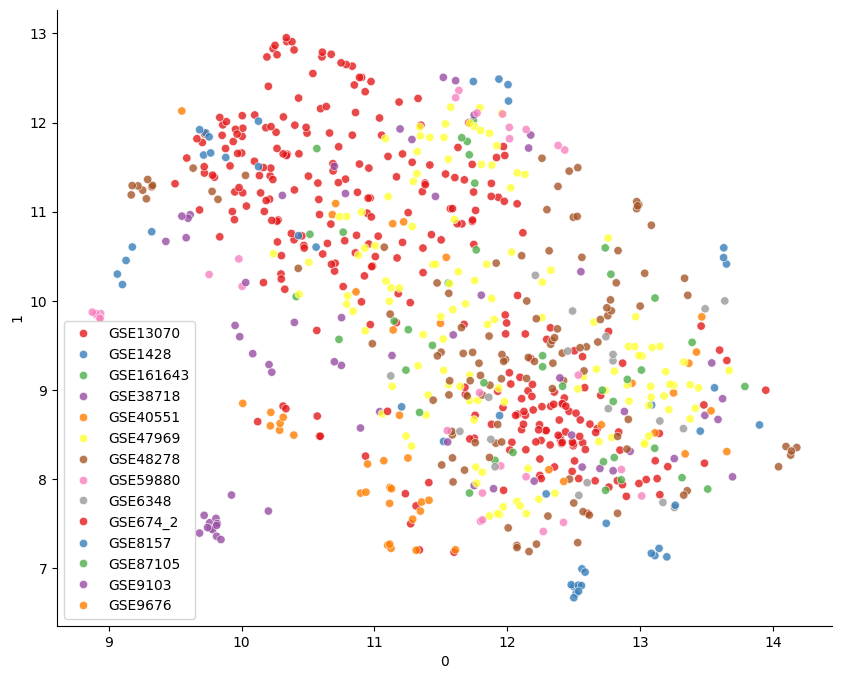

In [48]:
umap_projection(two_step_norm_df, colors=microarray_dataframe_original['Experiment'])

In [32]:
training_data

,Sample,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,...,AI571298,AA149545,C18318,AI219073,AI205180,AI363375,Experiment,Sex,Age,Status
0,GSM342677,590.911058,218.430512,710.150202,9403.392472,751.378792,1454.325626,2098.601536,-248.776765,-164.663163,...,337.739677,-1020.394303,144.849223,-16.569677,735.896923,334.954454,GSE13070,Male,54.37,IRd
1,GSM342678,3087.848094,738.750672,-498.774955,3583.900747,347.042056,840.549940,2163.307819,-344.397091,5.482057,...,160.042577,2390.902589,227.581357,142.508572,353.341420,196.984430,GSE13070,Male,49.12,IRd
2,GSM342679,1438.529838,-430.952195,-602.672381,538.553977,50.947409,-288.837977,17.666756,-464.605518,-248.944390,...,-76.198633,915.956936,10.906049,-29.341012,-155.372553,1.786660,GSE13070,Male,48.31,IRd � TZD
3,GSM342680,98.011349,396.909118,-1281.789691,3182.881594,886.856119,1015.625174,780.377963,-328.005051,108.756234,...,231.947371,-545.245742,-56.540510,12.917079,531.970660,16.660222,GSE13070,Male,46.87,IRd � TZD
4,GSM342683,-849.451525,684.683955,1114.042762,443.011786,370.785504,333.539739,-63.560513,292.844053,-42.396021,...,200.367569,-453.626314,28.350612,-30.655708,-110.164419,13.685501,GSE13070,unknow,45.51,NRd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,GSM244612,2406.099299,701.108201,-1511.249588,1053.347813,1063.794543,1999.797718,4134.643295,3646.460018,-540.334718,...,49.460921,427.395391,14.097092,11.147196,58.772322,57.393969,GSE9676,Female,65.10,NaN
727,GSM244613,-2452.532495,-2303.183241,-6452.190043,-3239.090434,180.763818,-422.587745,-7201.027058,-359.355911,-360.395781,...,49.460921,427.395391,14.097092,11.147196,58.772322,57.393969,GSE9676,Female,68.40,NaN
728,GSM244614,3331.993545,-617.837803,-1575.834487,1153.877996,2557.323530,216.936671,-1722.457066,1878.259639,-184.111785,...,49.460921,427.395391,14.097092,11.147196,58.772322,57.393969,GSE9676,Female,65.90,NaN
729,GSM244615,4938.451319,-626.296478,-2498.615690,821.964991,5427.681408,1750.702499,-3665.622647,1101.640844,-170.896095,...,49.460921,427.395391,14.097092,11.147196,58.772322,57.393969,GSE9676,Female,67.30,NaN


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


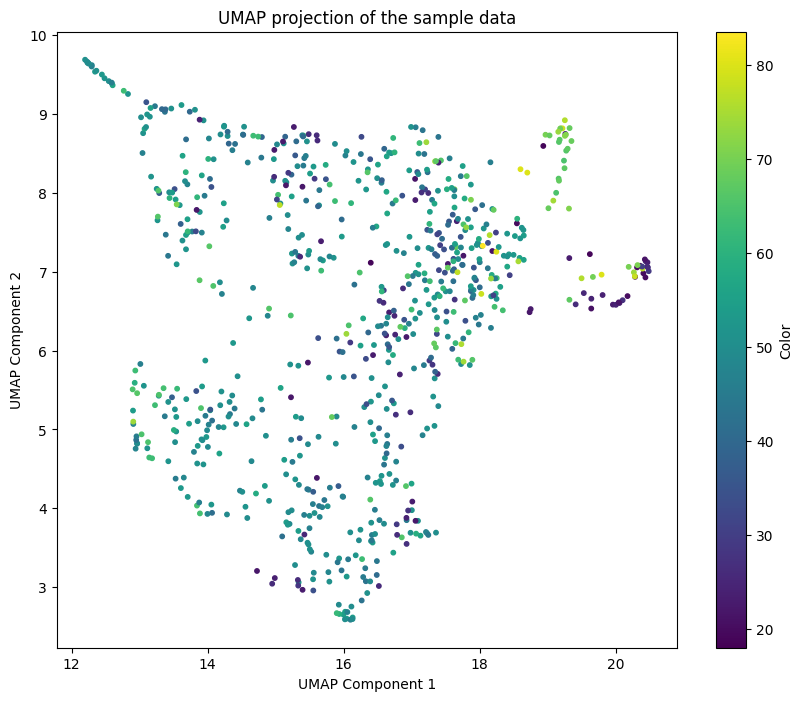

In [49]:
umap_projection(microarray_dataframe, colors=microarray_dataframe_original['Age'])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


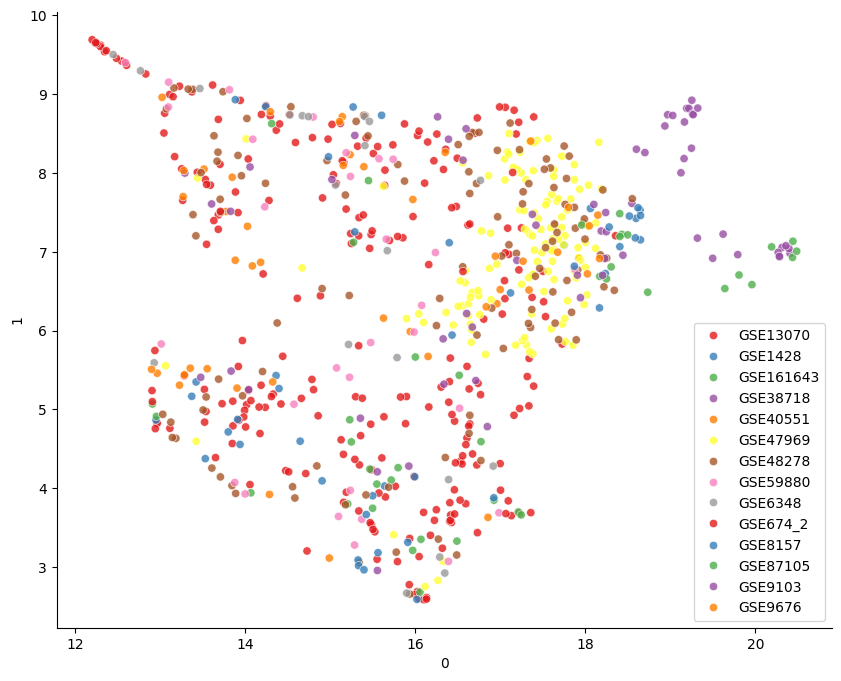

In [50]:
umap_projection(microarray_dataframe, colors=training_data['Experiment'])

In [35]:
two_step_norm_df["Age"]=microarray_dataframe_original["Age"]
two_step_norm_df["Experiment"]=microarray_dataframe_original["Experiment"]
two_step_norm_df["Sample"]=microarray_dataframe_original["Sample"]
two_step_norm_df.set_index("Sample", inplace=True)


In [36]:
two_step_norm_df.to_csv('Results/microarray_w_selected_genes_normalized.csv', index=True)

In [37]:
rnaseq_dataframe = pd.read_csv('Results/rnaseq_w_selected_genes.csv')
rnaseq_dataframe_original = pd.read_csv('Results/rnaseq_w_selected_genes.csv')
rnaseq_dataframe = m.remove_non_numeric_columns(rnaseq_dataframe)
rnaseq_dataframe.drop("Age", axis=1, inplace=True)
two_step_nom_array_rnaseq = two_step_normalization(rnaseq_dataframe.values)
two_step_nom_array_rnaseq = pd.DataFrame(two_step_nom_array_rnaseq, columns=rnaseq_dataframe.columns)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


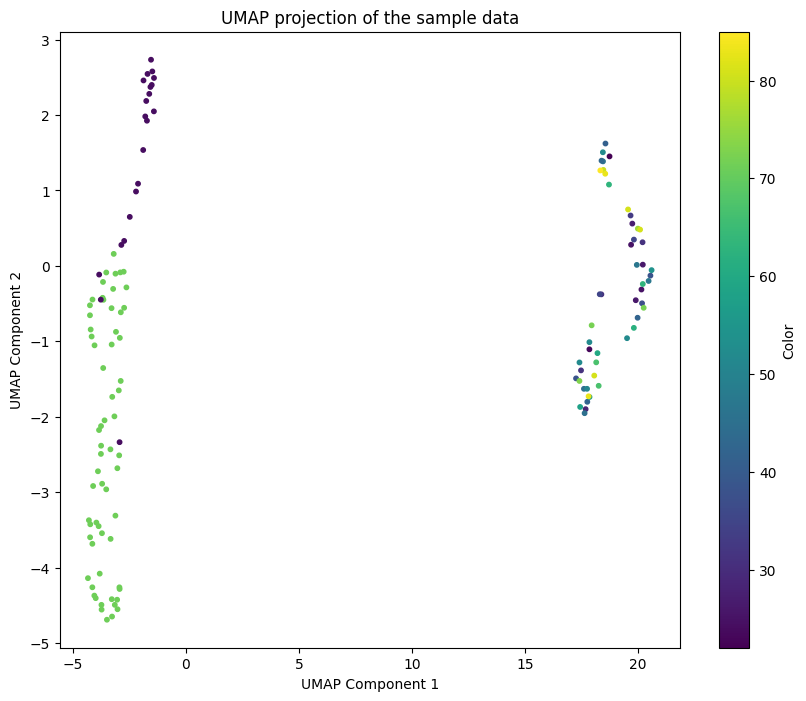

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


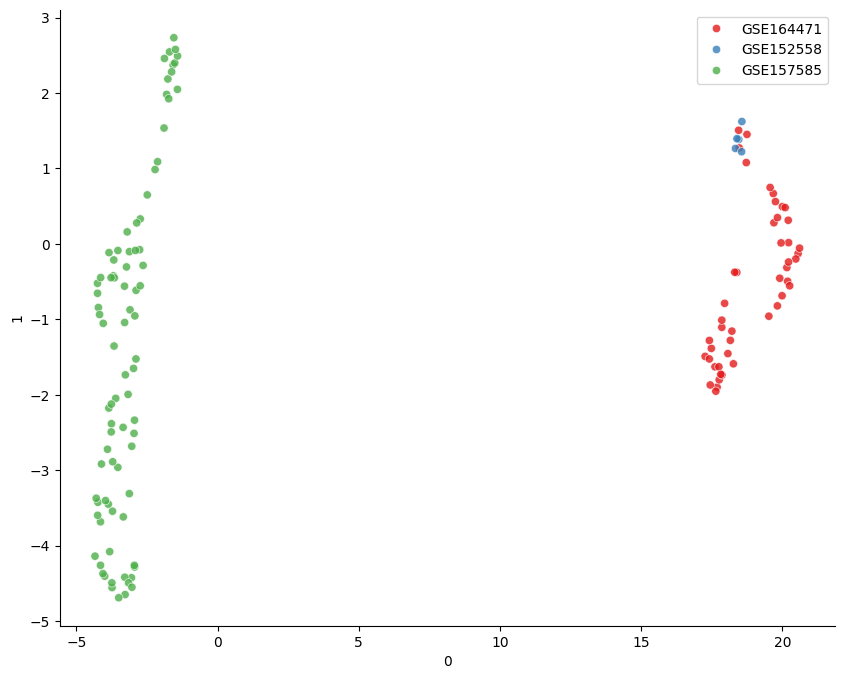

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


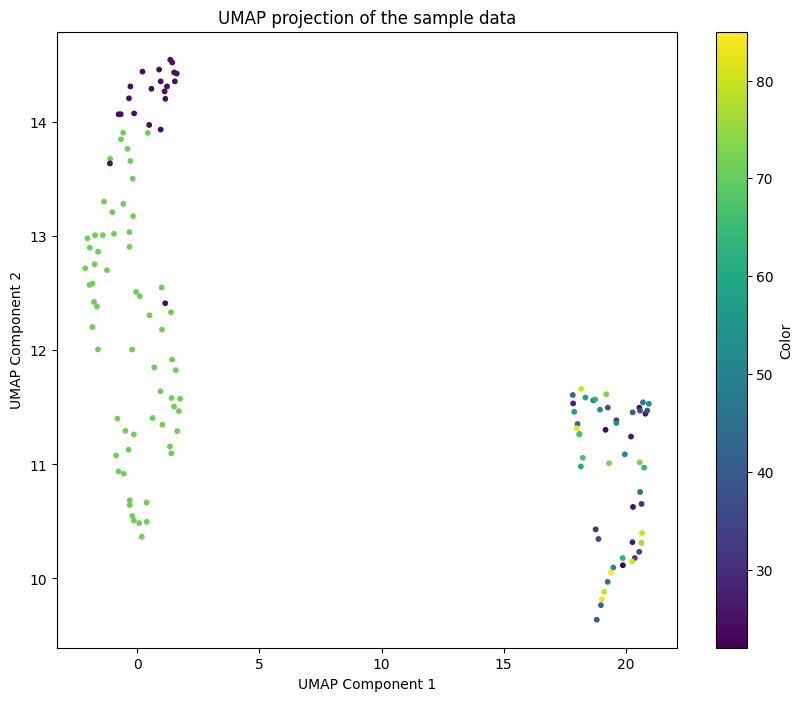

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


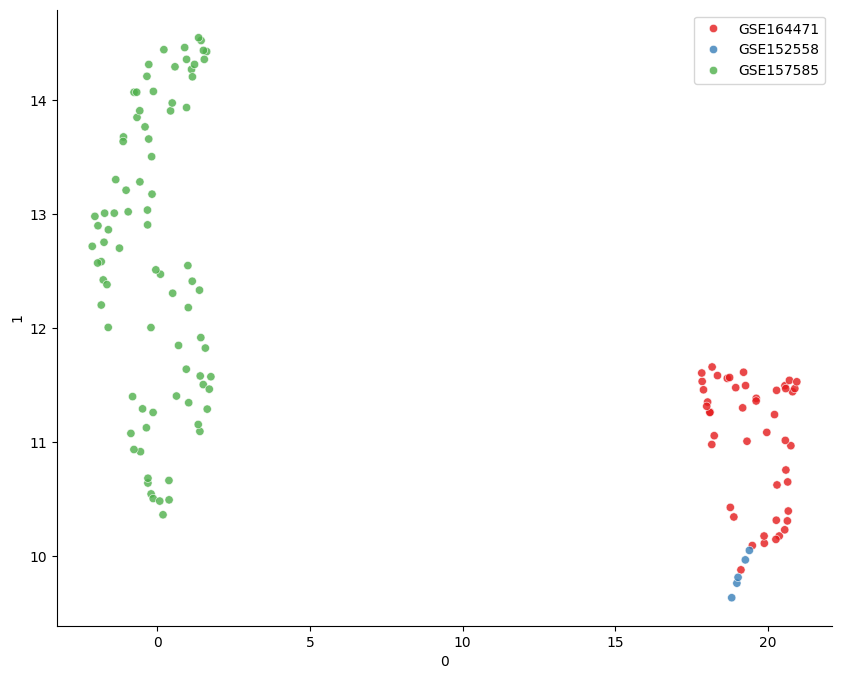

In [38]:
umap_projection(two_step_nom_array_rnaseq, colors=rnaseq_dataframe_original['Age'])
umap_projection(two_step_nom_array_rnaseq, colors=rnaseq_dataframe_original['Experiment'])
umap_projection(rnaseq_dataframe, colors=rnaseq_dataframe_original['Age'])
umap_projection(rnaseq_dataframe, colors=rnaseq_dataframe_original['Experiment'])

In [39]:
two_step_nom_array_rnaseq["Age"]=rnaseq_dataframe_original["Age"]
two_step_nom_array_rnaseq["Experiment"]=rnaseq_dataframe_original["Experiment"]
two_step_nom_array_rnaseq["Sample"]=rnaseq_dataframe_original["Sample"]
two_step_nom_array_rnaseq.set_index("Sample", inplace=True)
two_step_nom_array_rnaseq

,ENSG00000002726.20,ENSG00000006747.14,ENSG00000007541.16,ENSG00000010704.18,ENSG00000021645.18,ENSG00000033170.16,ENSG00000046889.18,ENSG00000053747.15,ENSG00000054611.13,ENSG00000058085.14,...,ENSG00000248383.4,ENSG00000254901.7,ENSG00000267534.3,ENSG00000270882.2,ENSG00000274618.1,ENSG00000275183.1,ENSG00000275379.1,ENSG00000276293.4,Age,Experiment
Sample,,,,,,,,,,,,,,,,,,,,,
SRR13388732,0.000765,0.032086,0.001554,0.006612,0.013259,0.064572,0.019599,0.022697,0.001575,0.003154,...,0.001276,0.028886,0.002243,0.001726,0.0,0.000000,0.000000,0.010339,23,GSE164471
SRR13388733,0.000170,0.004603,0.000124,0.001148,0.001564,0.034706,0.017604,0.009794,0.001549,0.000951,...,0.000254,0.006335,0.001012,0.003084,0.0,0.000214,0.000000,0.015191,28,GSE164471
SRR13388734,0.003212,0.014953,0.000627,0.004684,0.011978,0.077185,0.014149,0.010618,0.006523,0.002786,...,0.000884,0.035813,0.002802,0.000000,0.0,0.002156,0.000000,0.019217,31,GSE164471
SRR13388735,0.000000,0.007050,0.000870,0.002268,0.001994,0.028663,0.016534,0.008657,0.001539,0.000584,...,0.000155,0.007395,0.001717,0.010343,0.0,0.000644,0.000000,0.012312,31,GSE164471
SRR13388736,0.003805,0.045211,0.003368,0.007522,0.023626,0.179225,0.026546,0.025611,0.003730,0.006991,...,0.002054,0.041090,0.008263,0.004172,0.0,0.002022,0.002293,0.007587,35,GSE164471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR12604223,0.000089,0.001341,0.010918,0.000655,0.000077,0.002902,0.000023,0.001224,0.006200,0.000437,...,0.000033,0.008448,0.000690,0.002136,0.0,0.000252,0.000000,0.034680,24,GSE157585
SRR12604224,0.000184,0.000158,0.012410,0.001234,0.000035,0.001771,0.000064,0.000724,0.003711,0.000154,...,0.000000,0.006177,0.000265,0.000962,0.0,0.000141,0.000000,0.032741,24,GSE157585
SRR12604225,0.000159,0.001085,0.015831,0.001243,0.000166,0.001493,0.000047,0.000741,0.005962,0.000248,...,0.000000,0.005396,0.000343,0.004677,0.0,0.000087,0.000000,0.028666,24,GSE157585
